In [3]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
# Setting the dataset path

DATA_DIR = Path("../data/raw")

TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

print(TRAIN_DIR)
print(TEST_DIR)

..\data\raw\Training
..\data\raw\Testing


In [5]:
# displaying class names

classes = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])

classes

# .iterdir() is a method of Path objects from Python's pathlib module.
# It iterates (goes through) all the files and folders inside a directory, one by one.




['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

In [6]:
# Counting the number of images in each class 

for cls in classes:
    count = len(list((TRAIN_DIR / cls).glob("*")))
    print(f"{cls}: {count}")
    
#.glob("*") is a method of the Path class that returns all files
# and directories in the specified directory matching the given pattern (* means all items).

glioma_tumor: 826
meningioma_tumor: 822
no_tumor: 395
pituitary_tumor: 827


# EDA

In [1]:
from PIL import Image

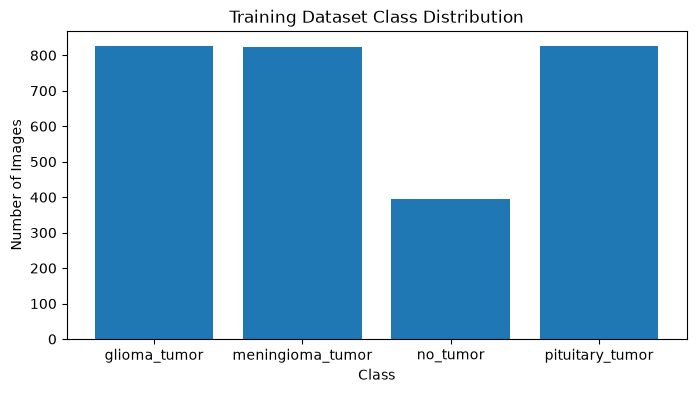

In [ ]:
# Number of images in each class

train_counts = {}

for cls in classes:
    train_counts[cls] = len(list((TRAIN_DIR / cls).glob("*")))

pd.DataFrame(
    train_counts.items(),
    columns=["Class", "Number of Images"]
)

plt.figure(figsize=(8,4))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

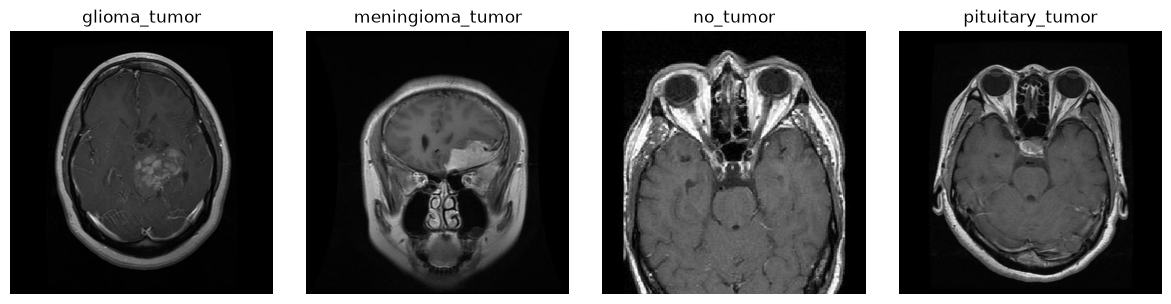

In [10]:
# Sample images from each class

from PIL import Image

plt.figure(figsize=(12, 3))

for i, cls in enumerate(classes):
    image_path = next((TRAIN_DIR / cls).glob("*"))  # Get the first image
    # next() returns the first image in the folder
    
    image = Image.open(image_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# Checking image size and mode

sample_image = next((TRAIN_DIR / classes[0]).glob("*"))

image = Image.open(sample_image)

print("Image Size:", image.size)
print("Image Mode:", image.mode)

Image Size: (512, 512)
Image Mode: RGB


In [13]:
# Checking all unique size of images

image_sizes = set()

for cls in classes:
    for image_path in (TRAIN_DIR / cls).glob("*"):
        image = Image.open(image_path)
        image_sizes.add(image.size)

print(image_sizes)
print(f"Number of different image size = {len(image_sizes)}")

{(491, 624), (206, 244), (409, 442), (503, 369), (430, 483), (728, 725), (201, 251), (289, 354), (554, 554), (236, 226), (214, 216), (229, 214), (733, 781), (229, 223), (235, 257), (411, 501), (329, 310), (645, 439), (434, 512), (227, 262), (528, 528), (590, 332), (209, 241), (407, 485), (630, 423), (300, 359), (236, 203), (502, 502), (236, 221), (236, 239), (550, 664), (226, 213), (411, 496), (1024, 830), (374, 456), (235, 261), (329, 314), (355, 452), (626, 686), (276, 326), (300, 345), (210, 213), (359, 449), (201, 250), (221, 228), (236, 216), (225, 225), (202, 223), (410, 490), (605, 613), (216, 234), (208, 248), (350, 350), (444, 506), (450, 446), (442, 442), (534, 674), (257, 307), (402, 396), (341, 377), (224, 219), (421, 486), (926, 649), (213, 237), (341, 395), (825, 993), (236, 220), (447, 251), (235, 233), (622, 777), (494, 600), (208, 243), (228, 221), (239, 248), (600, 605), (314, 260), (201, 249), (341, 372), (224, 223), (212, 236), (1365, 1365), (275, 301), (235, 228), 

In [ ]:
# Checking  format of all images

formats = set()

for cls in classes:
    for image_path in (TRAIN_DIR/cls).glob('*'):
        formats.add(image_path.suffix.lower())

print(formats)

{'.jpg'}


In [15]:
# Checking modes of all images

modes = set()

for cls in classes:
    for image_path in (TRAIN_DIR / cls).glob("*"):
        image = Image.open(image_path)
        modes.add(image.mode)

print(modes)

{'RGB'}


In [ ]:
# Checking for curropted images

corrupted = []

for cls in classes:
    for image_path in (TRAIN_DIR / cls).glob("*"):
        try:
            Image.open(image_path).verify()  #.verify() validates that an image file is not corrupted.
        except:
            corrupted.append(image_path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0
